In [2]:
# Install required packages
!pip install pandas matplotlib seaborn nltk wordcloud

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import pos_tag
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from nltk.util import ngrams

# Download NLTK resources
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('averaged_perceptron_tagger')  # CHANGED: Already included, but keeping for clarity
nltk.download('averaged_perceptron_tagger_eng')  # NEW: Added to fix LookupError

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


Mounted at /content/drive


In [3]:
# Load dataset
file_path = '/content/drive/MyDrive/MentalBERT_Project/data/suicidal_ideation_10K_v1.csv'
df = pd.read_csv(file_path)

# Inspect data
print("Dataset Info:")
print(df.info())
print("\nSample Rows:")
print(df.head())
print("\nSymptom Counts:")
print(df['symptom'].value_counts())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10000 non-null  object 
 1   created_at    10000 non-null  object 
 2   title         10000 non-null  object 
 3   selftext      10000 non-null  object 
 4   author        10000 non-null  object 
 5   score         10000 non-null  int64  
 6   upvote_ratio  10000 non-null  float64
 7   num_comments  10000 non-null  int64  
 8   over_18       10000 non-null  bool   
 9   symptom       10000 non-null  object 
dtypes: bool(1), float64(1), int64(2), object(6)
memory usage: 713.0+ KB
None

Sample Rows:
        id            created_at  \
0  1e5k7pm  2024-07-17T14:54:44Z   
1  1dokco3  2024-06-25T23:39:52Z   
2  1gr342o  2024-11-14T11:55:04Z   
3  1f1sjuu  2024-08-26T16:31:21Z   
4  1d4k94w  2024-05-31T01:46:24Z   

                                               title 

In [4]:
# Combine title and selftext
df['text'] = df['title'].fillna('') + ' ' + df['selftext'].fillna('')

# Clean text: lowercase, remove punctuation, stopwords
stop_words = set(stopwords.words('english'))
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text)  # Remove punctuation, numbers
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]  # Remove stopwords, short words
    return ' '.join(tokens)
df['clean_text'] = df['text'].apply(clean_text)

# Word count
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))
print("\nWord Count Stats:")
print(df['word_count'].describe())


Word Count Stats:
count    10000.00000
mean        76.67580
std         48.88318
min          0.00000
25%         39.00000
50%         62.00000
75%        102.00000
max        342.00000
Name: word_count, dtype: float64


In [5]:
# Word count
df['word_count'] = df['text'].apply(lambda x: len(x.split()))
print("\nWord Count Stats:")
print(df['word_count'].describe())


Word Count Stats:
count    10000.00000
mean       166.19860
std        105.88971
min         41.00000
25%         83.00000
50%        135.00000
75%        221.00000
max        517.00000
Name: word_count, dtype: float64


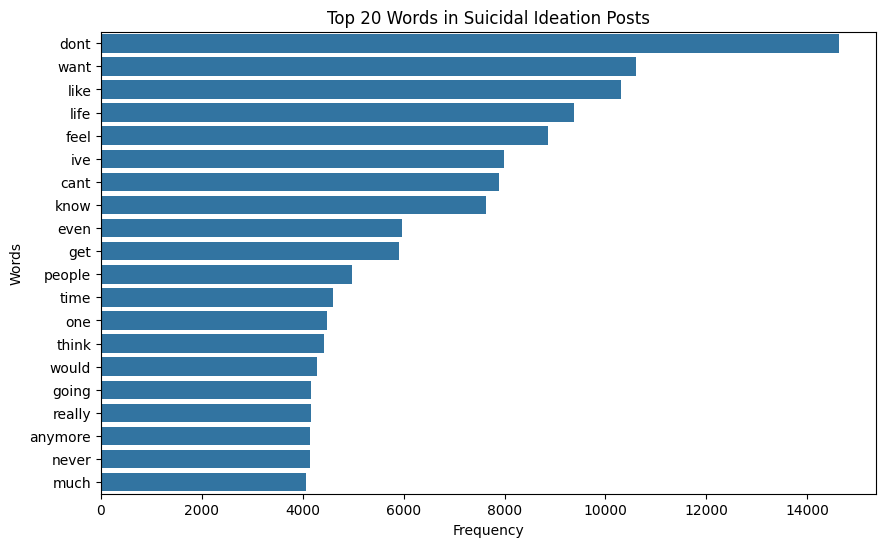

In [6]:
# Word frequencies
all_words = ' '.join(df['clean_text']).split()
word_freq = Counter(all_words)

top_words = word_freq.most_common(20)

words, counts = zip(*top_words)
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(words))
plt.title('Top 20 Words in Suicidal Ideation Posts')
plt.xlabel('Frequency')
plt.ylabel('Words')
plt.show()


In [7]:
print(top_words)

[('dont', 14628), ('want', 10606), ('like', 10313), ('life', 9369), ('feel', 8851), ('ive', 7994), ('cant', 7884), ('know', 7640), ('even', 5962), ('get', 5906), ('people', 4969), ('time', 4608), ('one', 4480), ('think', 4420), ('would', 4290), ('going', 4171), ('really', 4164), ('anymore', 4149), ('never', 4140), ('much', 4058)]


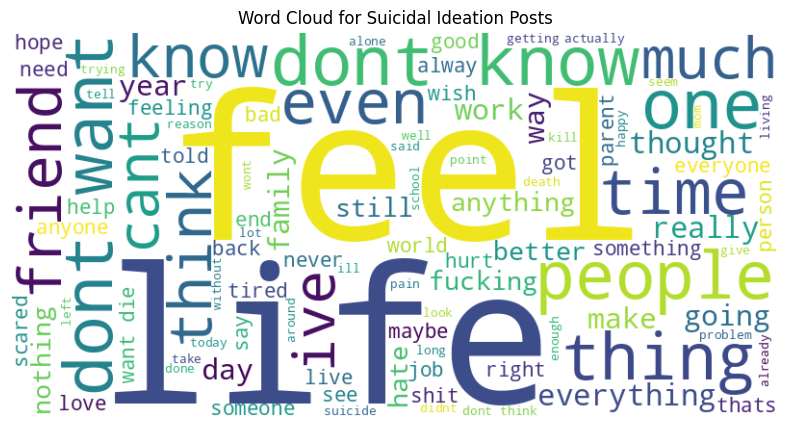

In [8]:
# Word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white', max_words=100, random_state=72).generate(' '.join(all_words))


plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Suicidal Ideation Posts')
plt.show()

In [9]:
# get ngrams
def get_ngrams(text, n):
    tokens = text.split()
    return list(ngrams(tokens, n))

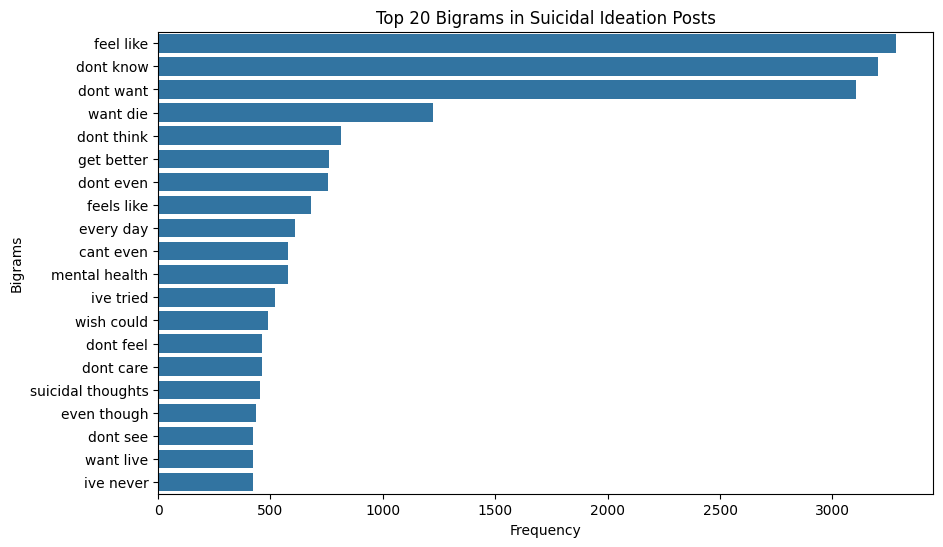

In [10]:
# Bigrams

bigrams = [bigram for text in df['clean_text'] for bigram in get_ngrams(text, 2)]
bigram_freq = Counter(bigrams)

# Bigram bar chart
top_bigrams = bigram_freq.most_common(20)
bigrams, counts = zip(*[( ' '.join(b), c) for b, c in top_bigrams])
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(bigrams))
plt.title('Top 20 Bigrams in Suicidal Ideation Posts')
plt.xlabel('Frequency')
plt.ylabel('Bigrams')
plt.show()

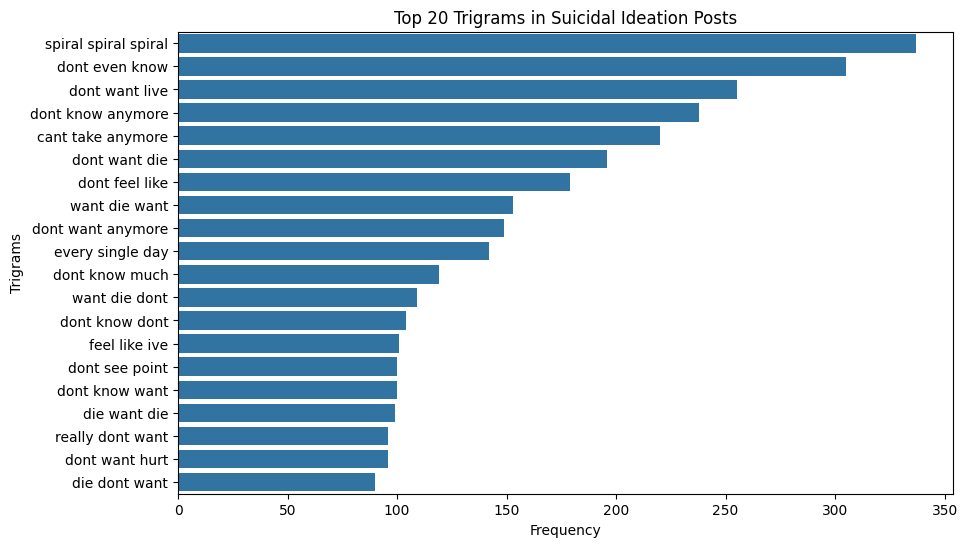

In [11]:
# Trigrams

trigrams = [trigram for text in df['clean_text'] for trigram in get_ngrams(text, 3)]
trigram_freq = Counter(trigrams)

# Trigram bar chart
top_trigrams = trigram_freq.most_common(20)
trigrams, counts = zip(*[( ' '.join(b), c) for b, c in top_trigrams])
plt.figure(figsize=(10, 6))
sns.barplot(x=list(counts), y=list(trigrams))
plt.title('Top 20 Trigrams in Suicidal Ideation Posts')
plt.xlabel('Frequency')
plt.ylabel('Trigrams')
plt.show()


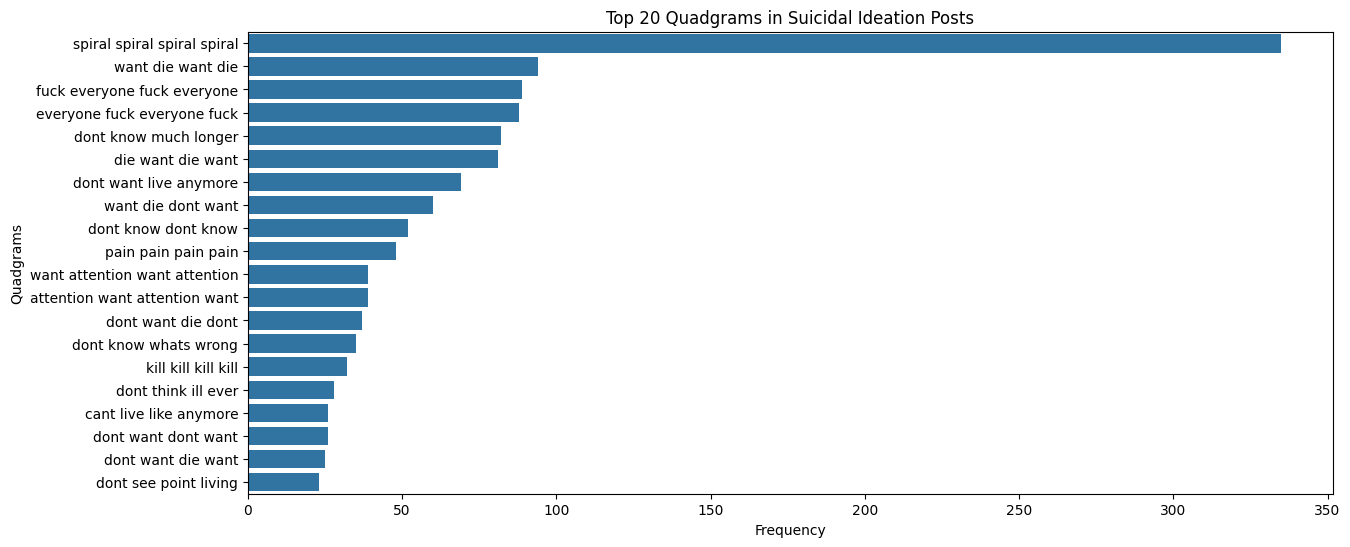

In [12]:
# Quadgrams
quadgrams = [quadgram for text in df['clean_text'] for quadgram in get_ngrams(text, 4)]
quadgram_freq = Counter(quadgrams)

# Quadgram bar chart
top_quadgrams = quadgram_freq.most_common(20)
quadgrams, counts = zip(*[(' '.join(q), c) for q, c in top_quadgrams])
plt.figure(figsize=(14, 6))
sns.barplot(x=list(counts), y=list(quadgrams))
plt.title('Top 20 Quadgrams in Suicidal Ideation Posts')
plt.xlabel('Frequency')
plt.ylabel('Quadgrams')
plt.show()

/tmp/ipython-input-4190545925.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df['year_month'] = pd.to_datetime(df['created_at']).dt.to_period('M')  # CHANGED: Removed unit='s' to parse ISO 8601 format


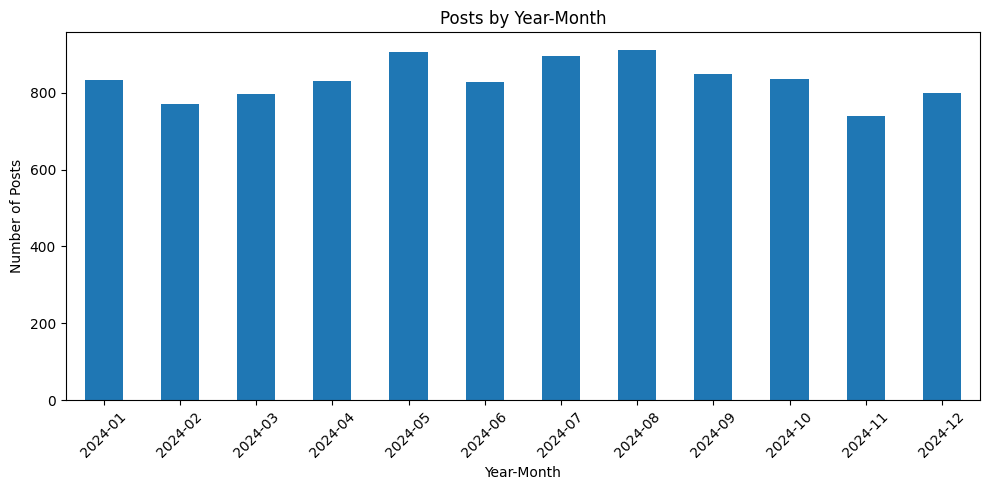

In [13]:

# Posts by year-month
df['year_month'] = pd.to_datetime(df['created_at']).dt.to_period('M')  # CHANGED: Removed unit='s' to parse ISO 8601 format
plt.figure(figsize=(10, 5))
df['year_month'].value_counts().sort_index().plot(kind='bar')
plt.title('Posts by Year-Month')
plt.xlabel('Year-Month')
plt.ylabel('Number of Posts')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

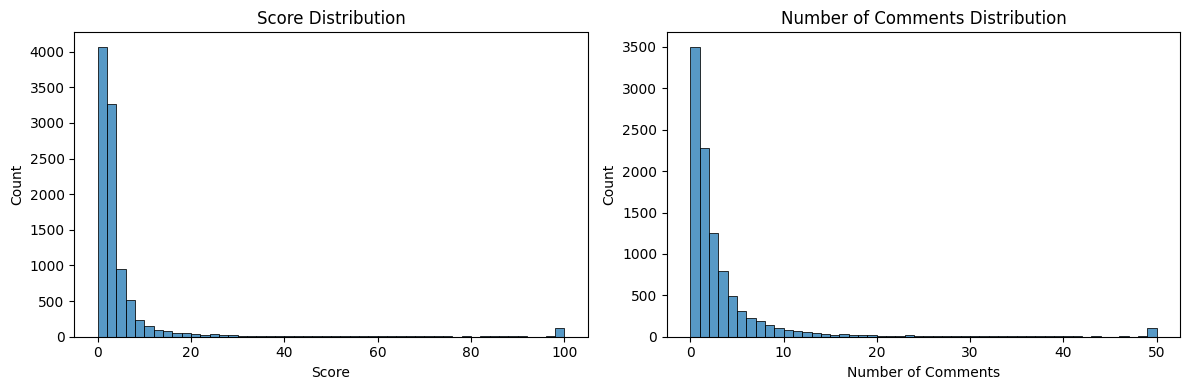

In [14]:
# Engagement distributions
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['score'].clip(upper=100), bins=50)
plt.title('Score Distribution')
plt.xlabel('Score')
plt.subplot(1, 2, 2)
sns.histplot(df['num_comments'].clip(upper=50), bins=50)
plt.title('Number of Comments Distribution')
plt.xlabel('Number of Comments')
plt.tight_layout()
plt.show()

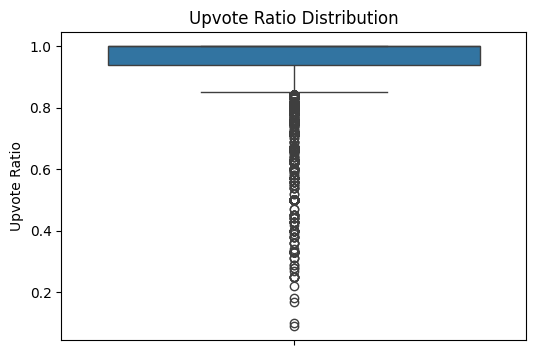

In [15]:
# Upvote ratio boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(y=df['upvote_ratio'])
plt.title('Upvote Ratio Distribution')
plt.ylabel('Upvote Ratio')
plt.show()

In [16]:
# Sentiment analysis
sid = SentimentIntensityAnalyzer()
df['sentiment'] = df['clean_text'].apply(lambda x: sid.polarity_scores(x)['compound'])
print("\nSentiment Stats:")
print(df['sentiment'].describe())



Sentiment Stats:
count    10000.00000
mean        -0.40935
std          0.71049
min         -0.99990
25%         -0.95860
50%         -0.82330
75%          0.17880
max          0.99820
Name: sentiment, dtype: float64


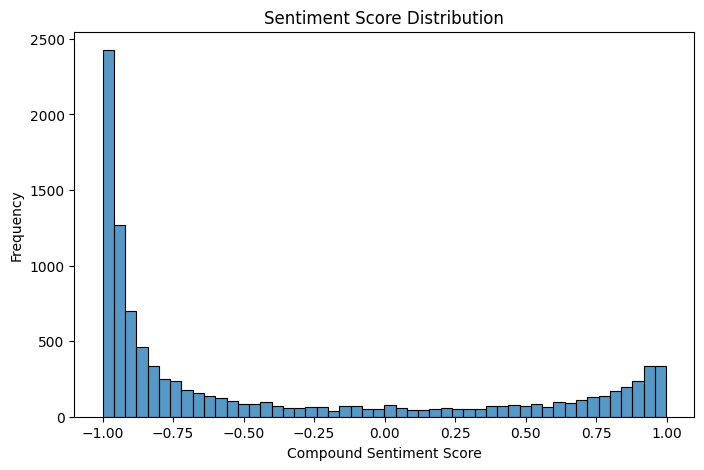

In [17]:
# Sentiment distribution

plt.figure(figsize=(8, 5))
sns.histplot(df['sentiment'], bins=50)
plt.title('Sentiment Score Distribution')
plt.xlabel('Compound Sentiment Score')
plt.ylabel('Frequency')
plt.show()


In [18]:
for col in df.columns:
    print(f"{col}: {df.iloc[0][col]}")

id: 1e5k7pm
created_at: 2024-07-17T14:54:44Z
title: I always wanted to die
selftext: Sorry for triggering but that's true. I think since I was 11 i wanted. Then it was like wish to make ppl realized how I suffer. Rn I cant stop thinking.  I just want to let go and down into this fantasy but I cant bc I have mine responsibilites. Month ago my Sister died(overdosed) and o feel even more empty. No friends, one year in new country- I didnt even get chance to finish higshool bc I was forced to move.And I m inteligent so it destroyed me that here they want me only to hand -working. I m an artist but rn i lost all my skills and i feel helpless. ll be 18 in month and all I want is die. I always knew I ll die this way but also I cant do it to ppl even if they care.  But something is really brocken in me and idk if it ll not break me whole in some random moment.
I need help but idk how to ask. I m asking my parents but they dont listen. I m scared to be adult, even if I always took care of mysel

In [19]:
# # POS tagging: adjectives
# def get_adjectives(text):
#     tokens = word_tokenize(text)
#     tagged = pos_tag(tokens)
#     return [word for word, pos in tagged if pos.startswith('JJ')]
# adjectives = [adj for text in df['clean_text'] for adj in get_adjectives(text)]
# adj_freq = Counter(adjectives)
# print("\nTop 10 Adjectives:", adj_freq.most_common(10))